In [1]:
import pandas as pd

In [2]:
print("Loading data...")
# 1. load the full data csv file into a pandas dataframe
df_full = pd.read_csv("../data/OnlineRetail.csv", encoding="unicode_escape")

# 2. get only 2000 rows randomly for faster processing
df = df_full.sample(n=2000, random_state=42)

# 3. check our data shape and columns
print("Data shape:", df.shape)
print("Columns:", df.columns)

# 4. check first 5 rows of the data
print("First 5 rows:")

df.head()

Loading data...
Data shape: (2000, 8)
Columns: Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')
First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,6/1/2011 12:05,0.85,17315.0,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,5/27/2011 17:14,6.95,14031.0,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,4/21/2011 17:05,0.65,14031.0,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,11/16/2011 10:39,1.95,17198.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,3/10/2011 8:40,9.95,13502.0,United Kingdom


In [3]:
# 5. check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
InvoiceNo        0
StockCode        0
Description      3
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID     514
Country          0
dtype: int64


In [4]:
print("Cleaning data...")

# 6. drop rows with missing CustomerID, Description
df_clean = df.dropna(subset=["CustomerID", 'Description'])

# 7. Remove returned items (Quantity <= 0) and free items (UnitPrice <= 0
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)].copy()

# 8. Create Total spend column
df_clean['TotalSpend'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean.isna().sum()

Cleaning data...


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalSpend     0
dtype: int64

In [5]:
print("Formatting InvoiceDate...")

# 9. Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print("Date formatting successful!")
# 10. Check if the data type has changed (InvoiceDate should be datetime64[ns])
print(df_clean[['InvoiceNo', 'InvoiceDate']].head())
print("\n--- Data Types ---")
print(df_clean[['InvoiceDate']].dtypes)

Formatting InvoiceDate...
Date formatting successful!
       InvoiceNo         InvoiceDate
209268    555200 2011-06-01 12:05:00
207108    554974 2011-05-27 17:14:00
167085    550972 2011-04-21 17:05:00
471836    576652 2011-11-16 10:39:00
115865    546157 2011-03-10 08:40:00

--- Data Types ---
InvoiceDate    datetime64[us]
dtype: object


#### හිතන්න අපි මේ AI සිස්ටම් එක හදන්නේ ලොකු Smart Casual ඇඳුම් විකුණන බ්‍රෑන්ඩ් එකකට කියලා. අපිට ඕනේ වෙනවා අපේ කඩේට එන මිනිස්සුන්ව හරියටම අඳුරගෙන එයාලට ගැළපෙන විදියට වෙන වෙනම මාකටින් (Marketing) කරන්න. එතනදි තමයි මේ අකුරු 3 පාවිච්චි වෙන්නේ:

- R - Recency (මෑතකාලීන බව): පාරිභෝගිකයා අන්තිමටම කඩෙන් බඩු ගත්තේ දවස් කීයකට කලින්ද? (ඊයේ කඩේට ආපු කෙනාට වඩා, අවුරුද්දකින් කඩේ පැත්තේ ආපු නැති කෙනෙක් ගැන අපි වෙනම තීරණයක් ගන්න ඕනෙනේ).

- F - Frequency (වාර ගණන): එයා කොච්චර නිතර කඩේට එනවද? (සමහරු හැම මාසෙම ඇවිත් අලුත් Polo T-shirts, Chinos අරන් යනවා ඇති. සමහරු එන්නේ අවුරුද්දකට සැරයක් වෙන්න පුළුවන්).

- M - Monetary (වියදම): එයා මුළු කාලය ඇතුළත කඩේට කොච්චර සල්ලි ගාණක් වියදම් කරලා තියෙනවද? (එකපාර රුපියල් ලක්ෂෙක බඩු ගත්ත කෙනෙකුයි, රුපියල් දාහක බඩු ගත්ත කෙනෙකුයි එක සමාන නෑනේ).

#### මේක පාවිච්චි කරන්නේ මොන වගේ Projects වලද?

- E-Commerce & Retail (අපි දැන් කරනවා වගේ): Amazon, Daraz, AliExpress වගේ සයිට් වල මේක ගොඩක් පාවිච්චි වෙනවා. හිතන්න කෙනෙක් කලින් ගොඩක් සල්ලි වියදම් කරලා (High M), හැබැයි දැන් මාස 3කින් කඩේට ඇවිත් නෑ (Low R). සිස්ටම් එක ඉබේම ඒ කෙනාව අඳුරගෙන, එයාව ආයෙත් ගෙන්නගන්න "Special 20% Discount" ඊමේල් එකක් යවනවා.

- Loyalty Programs: සුපිරි වෙළඳසැල් වල කාඩ් එකෙන් (Nexus, Cargills දත්ත වලින්) 'හොඳම පාරිභෝගිකයින්' සහ 'නැතිවීගෙන යන පාරිභෝගිකයින්' වෙන වෙනම අඳුරගෙන promotions හදන්න මේක පාවිච්චි කරනවා.

- Subscription සේවා: Gym එකකට එන අය, නැත්නම් Netflix වගේ සේවා පාවිච්චි කරන අයගෙන් අස් වෙලා යන්න කිට්ටු අයව කලින්ම අඳුරගන්න (Churn Prediction) මේක පදනමක් විදියට ගන්නවා.

In [6]:
print("Calculating RFM Values...")

# 11. Find Reference Date
# අපේ dataset එකේ තියෙන අලුත්ම දිනයට තව දවස් 1ක් එකතු කරනවා.
# (එතකොට අදම බඩු ගත්ත කෙනාගේ 'ගතවුණු දවස් ගාණ' 0 වෙන්නේ නැතුව 1 වෙනවා)
latest_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Latest date for RFM:", latest_date)

# 12. CustomerID එකෙන් Group කරලා R, F, M අගයන් වෙන වෙනම ගණනය කිරීම
rfm = df_clean.groupby('CustomerID').agg({
    # Recency: පදනම් දිනයෙන්, පාරිභෝගිකයාගේ අන්තිම දිනය (max) අඩු කරලා දවස් ගාණ ගැනීම
    'InvoiceDate': lambda x: (latest_date - x.max()).days,

    # Frequency: අනුපිටපත් නැති (unique) Invoices ගාණ ගැනීම
    'InvoiceNo': 'nunique',

    # Monetary: ඒ පාරිභෝගිකයාගේ මුළු වියදම් (TotalSpend) ඔක්කොම එකතු කිරීම (sum)
    'TotalSpend': 'sum'
})
# 13. Columns වල නම් අපිට තේරෙන විදියට 'Recency', 'Frequency', 'Monetary' කියලා වෙනස් කිරීම
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSpend': 'Monetary'
}, inplace=True)

print("RFM calculation completed!")
print(f"Full Customers Count: {rfm.shape[0]}")

rfm.head()

Calculating RFM Values...
Latest date for RFM: 2011-12-10 12:00:00
RFM calculation completed!
Full Customers Count: 941


,Recency,Frequency,Monetary
CustomerID,,,
12347.0,183,1,30.00
12353.0,204,1,39.80
12354.0,232,1,25.45
12360.0,52,1,33.90
12372.0,296,1,10.08


## Scaling RFM Values

#### ඇයි අපි මේක කරන්නේ?
අපේ RFM වගුව දිහා බැලුවොත් ඔයාට පේයි Frequency (වාර ගණන) තියෙන්නේ 1, 2, 5 වගේ පොඩි ඉලක්කම් වලින්. හැබැයි Monetary (වියදම) තියෙන්නේ 1500, 5000 වගේ ලොකු ඉලක්කම් වලින්.


අපි ඊළඟට පාවිච්චි කරන K-Means algorithm එක වැඩ කරන්නේ ලක්ෂ්‍යයන් අතර ගණිතමය දුර (Distance) මත පදනම් වෙලා. අපි මේක මේ විදියටම දුන්නොත් Model එක හිතනවා "Monetary අගය ලොකු නිසා ඒක තමයි වැදගත්ම දේ" කියලා. එතකොට අනිත් features දෙක model එකෙන් සම්පූර්ණයෙන්ම මගහැරෙනවා.

ඒක හදාගන්න අපි Scikit-learn වල තියෙන StandardScaler පාවිච්චි කරලා මේ ඔක්කොම එකම මට්ටමකට ගේමු.

In [7]:
from sklearn.preprocessing import StandardScaler
print("Scaling RFM values...")

# 14. StandardScaler එකෙන් RFM values scale කිරීම
scaler = StandardScaler()

# RFM දත්ත ටික scale කිරීම (Fit & Transform)
# මේකෙන් එන්නේ NumPy array එකක්
rfm_scaled_array = scaler.fit_transform(rfm)

# අපිට ලේසියෙන් කියවන්න පුළුවන් වෙන්න ඒක ආයෙත් Pandas DataFrame එකක් බවට පත් කිරීම
rfm_scaled = pd.DataFrame(rfm_scaled_array, index=rfm.index, columns=rfm.columns)

print("Scaling completed!")

rfm_scaled.head()

Scaling RFM values...
Scaling completed!


,Recency,Frequency,Monetary
CustomerID,,,
12347.0,0.365735,-0.251503,-0.013828
12353.0,0.553873,-0.251503,0.097772
12354.0,0.804722,-0.251503,-0.065642
12360.0,-0.807883,-0.251503,0.030584
12372.0,1.378093,-0.251503,-0.240671


## check clusters with K-Means use Elbow Method

Finding optimal number of clusters with Elbow Method...


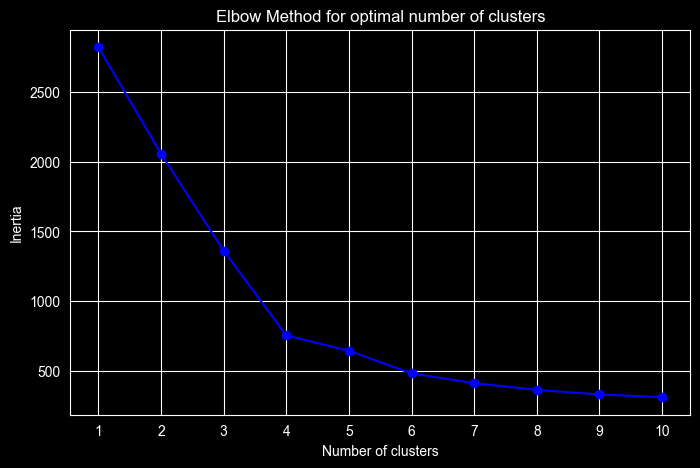

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

print("Finding optimal number of clusters with Elbow Method...")

# 15. K-Means algorithm එකෙන් clusters ගණන හොයාගන්න Elbow Method එකෙන්
inertias = []
ks = range(1, 11)  # 1 cluster එකෙන් 10 cluster එක දක්වා

for k in ks:
    # Model එක හැදීම (random_state=42 දෙන්නේ හැමවෙලේම එකම ප්‍රතිඵලය එන්නයි)
    kmeans = KMeans(n_clusters=k, random_state=42)
    # Scale කරපු දත්ත වලට model එක fit කිරීම
    kmeans.fit(rfm_scaled)
    # Inertia අගය list එකට එකතු කිරීම
    inertias.append(kmeans.inertia_)


# Elbow Method එකේ graph එක plot කිරීම
plt.figure(figsize=(8, 5))
plt.plot(ks, inertias, marker='o', color='blue')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for optimal number of clusters")
plt.xticks(ks)
plt.grid(True)
plt.show()


#### ප්‍රස්ථාරය දිහා බැලුවාම පැහැදිලිවම පේනවා $k=1$ ඉඳන් $k=4$ වෙනකම් රේඛාව වේගයෙන් පල්ලෙහාට බහිනවා (ඒ කියන්නේ Inertia එක වේගයෙන් අඩු වෙනවා). හැබැයි හරියටම $k=4$ දී තමයි වැලමිට වගේ නැවිලා, එතනින් එහාට රේඛාව තිරස් අතට වගේ යන්න පටන් ගන්නේ. ඒ කියන්නේ පාරිභෝගිකයින්ව කණ්ඩායම් 4කට වඩා කැඩුවා කියලා අපේ Model එකට අලුතෙන් ලොකු දෙයක් ඉගෙනගන්න ලැබෙන්නේ නෑ.ඉතින් අපේ ව්‍යාපාරයට ගැළපෙන හොඳම කණ්ඩායම් ගාණ (Clusters) 4 යි.

## Segmenting customers into 4 groups.

In [9]:
print("Segmenting customers into 4 groups...")

# 16. K-Means model එකෙන් 4 clusters වලට පාරිභෝගිකයින් වෙන් කිරීම
Kmeans = KMeans(n_clusters=4, random_state=42)

# Scale කරපු දත්ත model එකට දීලා, එක එක customer අයිති කණ්ඩායම (0, 1, 2, 3) හොයාගැනීම
# .fit_predict() එකෙන් එකපාරම Model එක train වෙලා උත්තරෙත් එනවා
cluster_labels = Kmeans.fit_predict(rfm_scaled)

# 17. Cluster labels (0, 1, 2, 3) RFM DataFrame එකට එක් කිරීම
rfm['Cluster'] = cluster_labels

print("Customer segmentation completed!")


Segmenting customers into 4 groups...
Customer segmentation completed!


In [10]:
# කණ්ඩායම් 4 ට කී දෙනා ගාණේ බෙදිලා ඉන්නවද කියලා බලමු
print("--- Customers per Cluster ---")
rfm['Cluster'].value_counts().sort_index()

--- Customers per Cluster ---


Cluster
0    361
1    573
2      3
3      4
Name: count, dtype: int64

In [11]:
# අපේ අවසාන වගුවේ මුල් පේළි 5 බලමු
print("\n--- Final RFM Table with Clusters ---")
rfm.head()


--- Final RFM Table with Clusters ---


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347.0,183,1,30.00,0
12353.0,204,1,39.80,0
12354.0,232,1,25.45,0
12360.0,52,1,33.90,1
12372.0,296,1,10.08,0


## Profiling the Clusters

In [12]:
print("Profiling the clusters (Business Interpretation)...")
# අපි මෙතනදී scale කරපු දත්ත නෙවෙයි, අපේ මුල් (සැබෑ අගයන් තියෙන) RFM වගුවම පාවිච්චි කරනවා
# එතකොට අපිට සැබෑ දවස් ගණන් සහ රුපියල් වලින්ම/ඩොලර් වලින්ම අගයන් බලාගන්න පුළුවන්

cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',      # සාමාන්‍ය දවස් ගාණ
    'Frequency': 'mean',    # සාමාන්‍ය වාර ගාණ
    'Monetary': ['mean', 'count'] # සාමාන්‍ය වියදම සහ කණ්ඩායමේ ඉන්න ගාණ
}).round(1)

print("\n--- Cluster Profiles ---")
cluster_profile

Profiling the clusters (Business Interpretation)...

--- Cluster Profiles ---


Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0         267.7       1.1     23.9   361
1          64.5       1.4     26.6   573
2           7.0      24.7    376.4     3
3          42.8       4.5   1099.7     4

- Cluster 0 - "Lost Customers" (නැතිවීගෙන යන අය): * හැසිරීම: Recency එක 267.7 යි. ඒ කියන්නේ මේ අය දවස් 267 කින් (මාස 8කින් විතර!) කඩේ පැත්තේ ඇවිත් නෑ. Frequency එක 1.1 යි.

  - තීරණය: මේ අය එක පාරක් මොනවා හරි අරගෙන ආයේ ආපු නැති අය. මේ අයට "We miss you - 50% Off" වගේ ලොකු offer එකක් යවලා ආයෙත් ගෙන්නගන්න ට්‍රයි කරන්න ඕනේ.

- Cluster 1 - "Everyday Customers" (සාමාන්‍ය පාරිභෝගිකයින්): * හැසිරීම: ගොඩක්ම ඉන්නේ මෙතන (573 ක්). Recency එක 64.5 යි (මාස 2කට කලින් ඇවිත්). හැබැයි Frequency (1.4) සහ වියදම (26.6) අඩුයි.

  - තීරණය: මේ අය තමයි අපේ කඩේ රඳාපවතින සාමාන්‍ය මිනිස්සු. මේ අයගේ වියදම වැඩි කරවන්න "Buy 2 Get 1 Free" වගේ දේවල් දෙන්න පුළුවන්.

- Cluster 2 - "Loyal VIPs" (විශ්වාසවන්තම නිතර එන අය): * හැසිරීම: Recency එක 7.0 යි (සතියකට කලිනුත් ඇවිත්!). Frequency එක 24.7 යි (නිතරම එනවා). වියදමත් 376.4 ක් තියෙනවා. ඉන්නේ 3 දෙනයි.

  - තීරණය: මේ අය තමයි අපේ හොඳම බ්‍රෑන්ඩ් එකේ පිස්සුව තියෙන අය. අලුත්ම ඇඳුමක් ආපු ගමන් මුලින්ම email එක යවන්න ඕනේ මේ අයටයි.

- Cluster 3 - "Big Spenders" (ලොකු මුදලක් වියදම් කරන අය): * හැසිරීම: ඔයා අඳුරගත්ත කට්ටිය! Frequency 4.5 යි, ඒත් වියදම 1099.7 යි.

  - තීරණය: මේ අයට Premium offers, VIP ලෝයල්ටි කාඩ් වගේ දේවල් දීලා දිගටම තියාගන්න ඕනේ.

## User-Item Matrix (පාරිභෝගික-භාණ්ඩ අනුකෘතිය) නිර්මාණය කිරීම

- පේළි (Rows): අපේ පාරිභෝගිකයෝ (CustomerID)

- තීරු (Columns): කඩේ තියෙන හැම භාණ්ඩයක්ම (Description)

- අගයන් (Values): අදාළ පාරිභෝගිකයා අදාළ භාණ්ඩයෙන් කෑලි කීයක් (Quantity) අරන් තියෙනවද කියන එක. (කිසිම දෙයක් අරන් නැති කොටු වලට අපි 0 දානවා, මොකද NMF වලට සෘණ අගයන් හරි හිස්තැන් හරි දෙන්න බෑනේ).

In [15]:
print("Creating the User-Item Matrix for NMF...")

# Pandas pivot_table පාවිච්චි කරලා Matrix එක හැදීම
# index = පේළි (Customers), columns = තීරු (Items), values = අගයන් (Quantity)
# aggfunc='sum' දෙන්නේ එකම කෙනා දවස් දෙකකදී එකම බඩුව අරන් තිබුණොත් ඒක එකතු වෙන්නයි
# fill_value=0 දෙන්නේ, ගත්තේ නැති බඩු වලට හිස්තැන් (NaN) වෙනුවට 0 වැටෙන්නයි.

user_item_matrix = df_clean.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)
print("User-Item Matrix created successfully!")
print("Matrix shape:", user_item_matrix.shape)
print("Customer counts:")
print(user_item_matrix.shape[0])
print("Item counts:")
print(user_item_matrix.shape[1])


Creating the User-Item Matrix for NMF...
User-Item Matrix created successfully!
Matrix shape: (941, 949)
Customer counts:
941
Item counts:
949


In [16]:
# මුල් පේළි 5 සහ මුල් භාණ්ඩ 5 විතරක් (0 න් පිරිලා තියෙන විදිය) බලමු
print("--- User-Item Matrix Sample ---")
user_item_matrix.iloc[:5, :5]

--- User-Item Matrix Sample ---


Description,12 MESSAGE CARDS WITH ENVELOPES,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE WOODLAND
CustomerID,,,,,
12347.0,0,0,0,0,0
12353.0,0,0,0,0,0
12354.0,0,0,0,0,0
12360.0,0,0,0,0,0
12372.0,0,0,0,0,0


#### හැමතැනම 0 තියෙන්න හේතුව මේකයි:
- හිතන්න ඔයා Keells එකට හරි Cargills එකට හරි යනවා කියලා. ඒ කඩේ ඇතුළේ වෙනස් ජාතියේ බඩු (Items) 10,000 ක් විතර තියෙනවා. හැබැයි ඔයාගේ ට්‍රොලි එකේ තියෙන්නේ බඩු ජාති 20 ක් විතරයිනේ. ඉතින් අපි ඔයාගේ නම ගහලා, කඩේ තියෙන බඩු 10,000 ම ලැයිස්තුගත කළොත්, ඔයා ගත්තු බඩු 20 ට විතරක් ඉලක්කම් වැටිලා, ඉතුරු බඩු 9,980 ටම වැටෙන්නේ 0 නේද?

- අපේ මේ දත්ත සෙට් එකෙත් පාරිභෝගිකයෝ 941 ක් හිටියට, කඩේ තියෙන වෙනස් බඩු වර්ග ගාණ 949 යි. හැබැයි එක පාරිභෝගිකයෙක් සාමාන්‍යයෙන් අරන් තියෙන්නේ බඩු වර්ග 5 ක් හෝ 10 ක් විතරයි. ඒ නිසා අනිත් හැම කොටුවකටම ඉබේම 0 වැටෙනවා.

- Data Science වලදී අපි මේ වගේ 0 වලින් පිරිලා තියෙන වගු වලට කියන්නේ **"Sparse Matrix"** (විරල අනුකෘතිය) කියලයි.

## NMF Model එක Train කිරීම

In [19]:
from sklearn.decomposition import NMF

print("Applying NMF to learn purchasing patterns...")
#  NMF model එක හැදීම
# (අපි n_components=15 කියලා ගමු. ඒ කියන්නේ අර බඩු 949 න්, ප්‍රධාන 'රටාවන්' හෝ 'කට්ටල' 15 ක් AI එකට හොයාගන්න දෙනවා)
nmf_model = NMF(n_components=15, random_state=42)

# අර 0 පිරිච්ච Matrix එක NMF එකට දීලා train කිරීම (fit_transform)
# මේකෙන් පාරිභෝගිකයින්ව අර රටාවන් 15 ට අදාළව නියෝජනය කරනවා
nfm_features = nmf_model.fit_transform(user_item_matrix)

print("NMF model training completed!")
print(f"මුල් Matrix එකේ හැඩය (Customers, Items): {user_item_matrix.shape}")
print("NMF features shape:", nfm_features.shape)

Applying NMF to learn purchasing patterns...
NMF model training completed!
මුල් Matrix එකේ හැඩය (Customers, Items): (941, 949)
NMF features shape: (941, 15)


අපි දැන් එක පාරිභෝගිකයෙක්ව තෝරගෙන, එයාට ගැලපෙනම අනිත් පාරිභෝගිකයෝ කවුද කියලා හොයන්න යන්නේ.මේකට අපි පාවිච්චි කරන්නේ Cosine Similarity (කෝසයින් සමානතාව). ඔයාගේ Neural-Math-Engine එකටත් මේ ලොජික් එක කෙලින්ම දාන්න පුළුවන්.ගණිතමය විදියට දෛශික (vectors) දෙකක් අතර කෝණය හොයන සමීකරණය:$$\cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$$අපි අර Scikit-learn වල තියෙන normalize() පාවිච්චි කළාම, මේ හැම vector එකකම දිග 1 වෙනවා. එතකොට යට තියෙන බෙදීම අයින් වෙලා, කෙලින්ම Dot Product එකෙන් ($\mathbf{A} \cdot \mathbf{B}$) උත්තරේ එනවා!

In [21]:
from sklearn.preprocessing import normalize
print("Building the Recommender Engine (Cosine Similarity)...")

# 1. NMF features ටික normalize කිරීම (දිග 1 වෙන vector බවට පත් කිරීම)
norm_features = normalize(nfm_features)

# 2. DataFrame එකක් හැදීම (Index එක විදියට අපේ මුල් matrix එකේ CustomerID දානවා)
df_features = pd.DataFrame(norm_features, index=user_item_matrix.index)

# 3. අපි ටෙස්ට් කරන්න එක පාරිභෝගිකයෙක්ව තෝරගමු (පළවෙනි කෙනා)
sample_customer_id = user_item_matrix.index[0]
print(f"Customer ID: {sample_customer_id}")

# 4. ඒ පාරිභෝගිකයාගේ දත්ත පේළිය වෙන් කරගැනීම (A)
customer_profile = df_features.loc[sample_customer_id]

# 5. Cosine Similarity ගණනය කිරීම (මුළු වගුවම ඒ තනි පාරිභෝගිකයාගෙන් Dot product කිරීම)
similarities = df_features.dot(customer_profile)

# 6. වැඩිම සමානකමක් තියෙන (Top 5) පාරිභෝගිකයින් හොයාගැනීම
print(f"\n--- Customer {sample_customer_id} ට සමානම පාරිභෝගිකයින් 5 දෙනා ---")
# nlargest(6) ගන්නේ, පළවෙනි උත්තරේ එන්නේ 1.0 කින් තෝරගත්තු කෙනාම නිසා අනිත් 5 දෙනාව ගන්නයි
print(similarities.nlargest(6))

Building the Recommender Engine (Cosine Similarity)...
Customer ID: 12347.0

--- Customer 12347.0 ට සමානම පාරිභෝගිකයින් 5 දෙනා ---
CustomerID
15845.0    1.764679e-16
17231.0    1.764011e-16
16424.0    1.764008e-16
13870.0    1.764008e-16
14307.0    1.764004e-16
16187.0    1.763573e-16
dtype: float64


In [22]:
print("Final Recommender Engine!\n")

def recommend_items(target_customer_id, user_matrix, feature_matrix, top_n=3):
    try:
        # 1. සමානතා ගණනය කිරීම
        similarities = feature_matrix.dot(feature_matrix.loc[target_customer_id])

        # 2. තමන්වම (1.0) අයින් කරලා, ඊළඟට ඉන්න සමානම කෙනාව හොයාගැනීම
        # අගය 0 ට වඩා වැඩි, හොඳම ගැලපීම හොයමු
        similar_customers = similarities[similarities < 0.99].sort_values(ascending=False)
        best_match_id = similar_customers.index[0]
        match_score = similar_customers.iloc[0]

        print(f"[{target_customer_id}] ට සමානම පාරිභෝගිකයා: {best_match_id} (සමානතා අගය: {match_score:.4f})")

        # 3. Best Match ගත්තු බඩු ටික ලැයිස්තුගත කිරීම
        best_match_items = user_matrix.loc[best_match_id]
        best_match_bought = best_match_items[best_match_items > 0].index.tolist()

        # 4. අපේ Target Customer ගත්තු බඩු ටික ලැයිස්තුගත කිරීම
        target_customer_items = user_matrix.loc[target_customer_id]
        target_customer_bought = target_customer_items[target_customer_items > 0].index.tolist()

        # 5. Target Customer තාම අරන් නැති, හැබැයි Best Match ගත්තු බඩු ටික වෙන් කිරීම (The Magic!)
        recommendations = [item for item in best_match_bought if item not in target_customer_bought]

        print(f"\nඔබ මේ භාණ්ඩ වලටත් කැමති විය හැකියි (Top {top_n} Recommendations):")
        if not recommendations:
            print("  -> කණගාටුයි, අලුත් නිර්දේශ කිසිවක් හමු නොවීය.")
        else:
            for i, item in enumerate(recommendations[:top_n], 1):
                print(f"  {i}. {item}")

    except KeyError:
        print("මෙම පාරිභෝගිකයා දත්ත ගොනුවේ නොමැත!")

# අපි වෙනත් පාරිභෝගිකයෙක් (උදාහරණයක් ලෙස: 12353.0) පාවිච්චි කරලා සිස්ටම් එක ටෙස්ට් කරමු
recommend_items(12353.0, user_item_matrix, df_features)

Final Recommender Engine!

[12353.0] ට සමානම පාරිභෝගිකයා: 14680.0 (සමානතා අගය: 0.0000)

ඔබ මේ භාණ්ඩ වලටත් කැමති විය හැකියි (Top 3 Recommendations):
  1. CHARLOTTE BAG PINK POLKADOT
  2. ROUND SNACK BOXES SET OF 4 FRUITS 


In [23]:
recommend_items(14680.0, user_item_matrix, df_features)


[14680.0] ට සමානම පාරිභෝගිකයා: 15311.0 (සමානතා අගය: 0.9893)

ඔබ මේ භාණ්ඩ වලටත් කැමති විය හැකියි (Top 3 Recommendations):
  1. 200 RED + WHITE BENDY STRAWS
  2. 3 HOOK PHOTO SHELF ANTIQUE WHITE
  3. FELT EGG COSY CHICKEN
